In [1]:
import pyflubl
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak

initializing ocelot...


In [2]:
o = pyflubl.Analysis.PyflublOutput(jsonFileName="./pyflubl.json",
                                   jsonCoordinateFileName="./IPAC_2026_coordinate.json",
                                   rootFileName="./IPAC_2026001_pyflubl.root",
                                   dumpFileName="./IPAC_2026001_dump",
                                   usrbinFileName="./IPAC_2026001_fort.24")

Read 2 detectors
No statistics


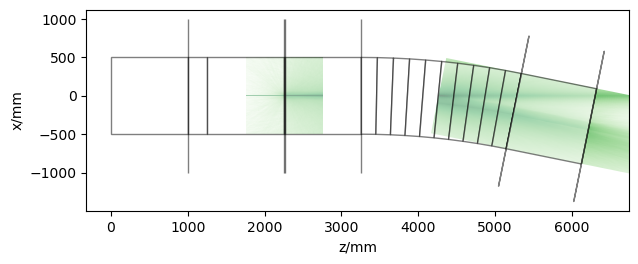

In [8]:
o.plot_projection(eventNumber=-1, detector=-1)
plt.savefig("IPAC_2026_usrbin.pdf")

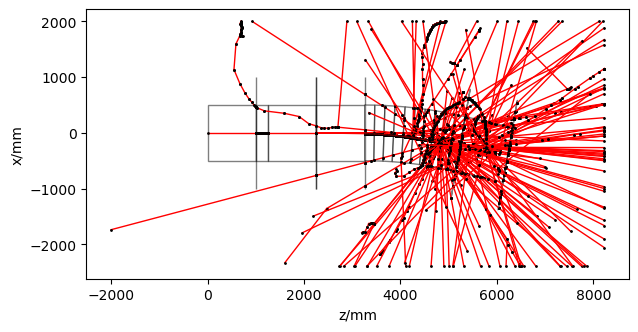

In [9]:
o.plot_projection(eventNumber=0,detector=None)
plt.savefig("IPAC_2026_dump.png")

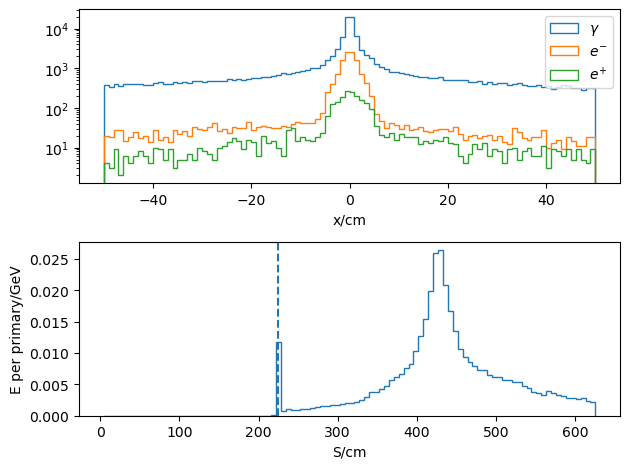

In [14]:
plt.subplot(2,1,1)
s4x = np.array(ak.flatten(o.uprootTree['s4.x'].array(library="ak")))
s4pid = np.array(ak.flatten(o.uprootTree['s4.partID'].array(library="ak")))
plt.hist(s4x[s4pid==7.0],100, (-50,50), label="$\gamma$", histtype="step");
plt.hist(s4x[s4pid==3.0],100, (-50,50), label="$e^{-}$", histtype="step");
plt.hist(s4x[s4pid==4.0],100,  (-50,50), label="$e^{+}$", histtype="step");
plt.yscale("log")
plt.xlabel("x/cm")
plt.legend();

plt.subplot(2,1,2)
Eloss_E = np.array(ak.flatten(o.uprootTree['eloss.E'].array(library="ak")))/10000
Eloss_S = np.array(ak.flatten(o.uprootTree['eloss.S'].array(library="ak")))
plt.hist(Eloss_S, 100, weights=Eloss_E, histtype="step")
plt.xlabel("S/cm")
plt.ylabel("E per primary/GeV")

plt.axvline(225,ls="--")

plt.tight_layout()
plt.savefig("IPAC_2026_root.pdf")

In [11]:
import pybdsim

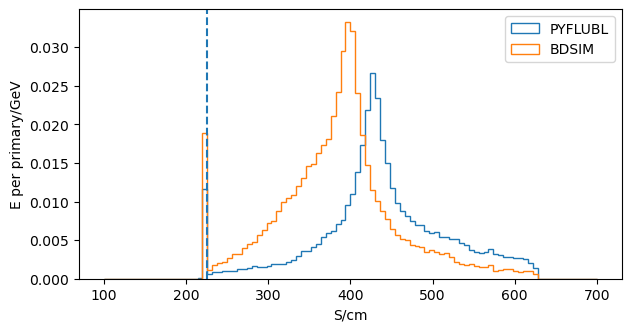

In [15]:
plt.figure(figsize=(7,3.5))
d = pybdsim.DataPandas.Load("./IPAC_2026.root")
el = d.get_eloss()

Eloss_E = np.array(ak.flatten(o.uprootTree['eloss.E'].array(library="ak")))
Eloss_S = np.array(ak.flatten(o.uprootTree['eloss.S'].array(library="ak")))
plt.hist(Eloss_S, 100, (100,700), weights=Eloss_E/10000, histtype="step", label="PYFLUBL")
plt.hist(el['S']*100, 100,(100,700), weights=el['energy']/10000, histtype="step", label="BDSIM");

plt.axvline(225,ls="--")

plt.xlabel("S/cm")
plt.ylabel("E per primary/GeV")
plt.legend()
# plt.yscale("log")

plt.savefig("IPAC_2026_comparision.pdf")

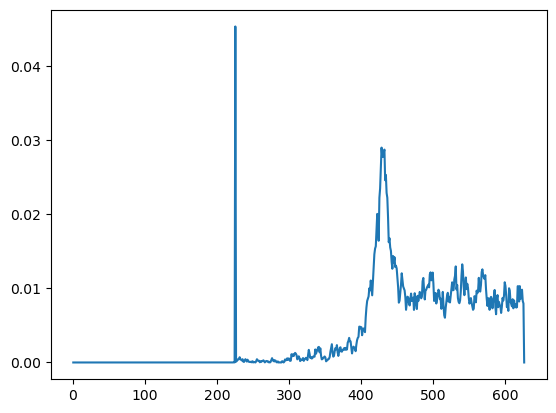

In [112]:
eloss_h = d.get_histo1d("ElossHisto")
plt.plot(eloss_h.xcentres*100, eloss_h.contents*0.01)

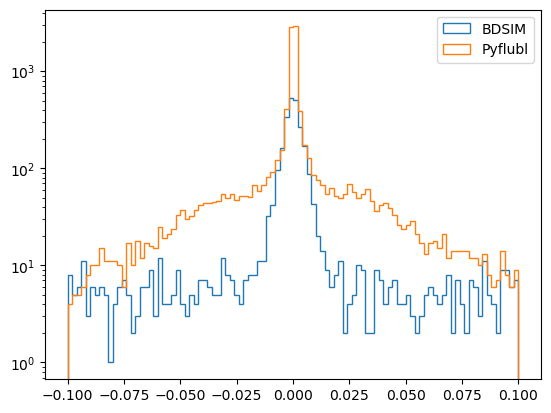

In [187]:
bdsim_samp_c = d.get_sampler("c.")
fluka_samp_x = np.array(ak.flatten(o.uprootTree['s3.x'].array(library="ak")))
fluka_samp_y = np.array(ak.flatten(o.uprootTree['s3.y'].array(library="ak")))
fluka_samp_xp = np.array(ak.flatten(o.uprootTree['s3.xp'].array(library="ak")))
fluka_samp_yp = np.array(ak.flatten(o.uprootTree['s3.yp'].array(library="ak")))
plt.hist(samp_c['xp'],100, (-0.1,0.1), histtype="step", label="BDSIM");
plt.hist(fluka_samp_xp/10,100, (-0.1, 0.1), histtype="step", label="Pyflubl");
plt.yscale("log")
plt.legend()

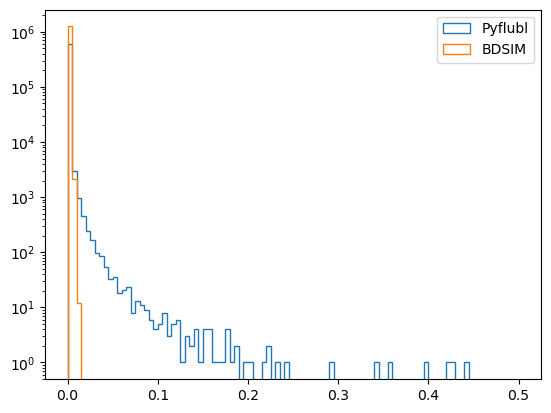

In [188]:
plt.hist(Eloss_E,100,(0,0.5),histtype="step", label="Pyflubl");
plt.hist(el['energy'],100,(0,0.5), histtype="step", label="BDSIM");
plt.yscale("log")
plt.legend()

In [ ]:
d_1mm = pybdsim.DataPandas.Load("./IPAC_2026_1mm.root")
d_1cm = pybdsim.DataPandas.Load("./IPAC_2026_1cm.root")
d_10cm = pybdsim.DataPandas.Load("./IPAC_2026_10cm.root")
el_1mm = d_1mm.get_eloss()
el_1cm = d_1cm.get_eloss()
el_10cm = d_10cm.get_eloss()

plt.hist(el_1mm['S']*100, 100,(100,700), weights=el_1mm['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_1cm['S']*100, 100,(100,700), weights=el_1cm['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_10cm['S']*100, 100,(100,700), weights=el_10cm['energy']/1000, histtype="step", label="BDSIM");

In [ ]:
d_em = pybdsim.DataPandas.Load("./IPAC_2026_1cm.root")
d_em1 = pybdsim.DataPandas.Load("./IPAC_2026_em1.root")
d_em2 = pybdsim.DataPandas.Load("./IPAC_2026_em2.root")
d_em3 = pybdsim.DataPandas.Load("./IPAC_2026_em3.root")
d_em4 = pybdsim.DataPandas.Load("./IPAC_2026_em4.root")


el_em = d_em.get_eloss()
el_em1 = d_em1.get_eloss()
el_em2 = d_em2.get_eloss()
el_em3 = d_em3.get_eloss()
el_em4 = d_em4.get_eloss()

plt.hist(el_em['S']*100, 100,(100,700), weights=el_em['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_em1['S']*100, 100,(100,700), weights=el_em1['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_em2['S']*100, 100,(100,700), weights=el_em2['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_em3['S']*100, 100,(100,700), weights=el_em3['energy']/1000, histtype="step", label="BDSIM");
plt.hist(el_em4['S']*100, 100,(100,700), weights=el_em4['energy']/1000, histtype="step", label="BDSIM");